In [ ]:
import sys
sys.path.append('../')
from src.dataset import cargar_dataset_completo
from src.preprocesamiento import pipeline_preprocesamiento

df_eeg = cargar_dataset_completo('../data/raw/')
print("Aplicando filtros y normalización...")
df_eeg['senal_limpia'] = df_eeg['senal'].apply(pipeline_preprocesamiento)

# Guardar para la Fase 4
df_eeg.drop(columns=['senal'], inplace=True)
df_eeg.to_pickle('../data/processed/dataset_preprocesado.pkl')
print("Datos guardados en data/processed/")

Aplicando filtros y normalización...
Datos guardados en data/processed/


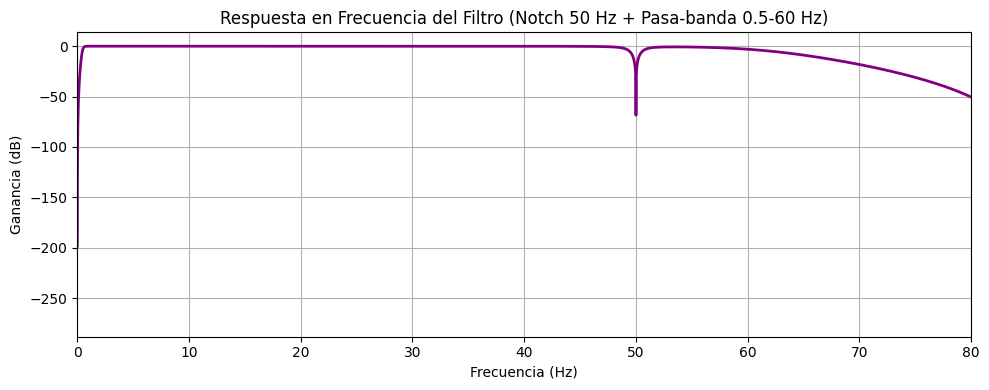

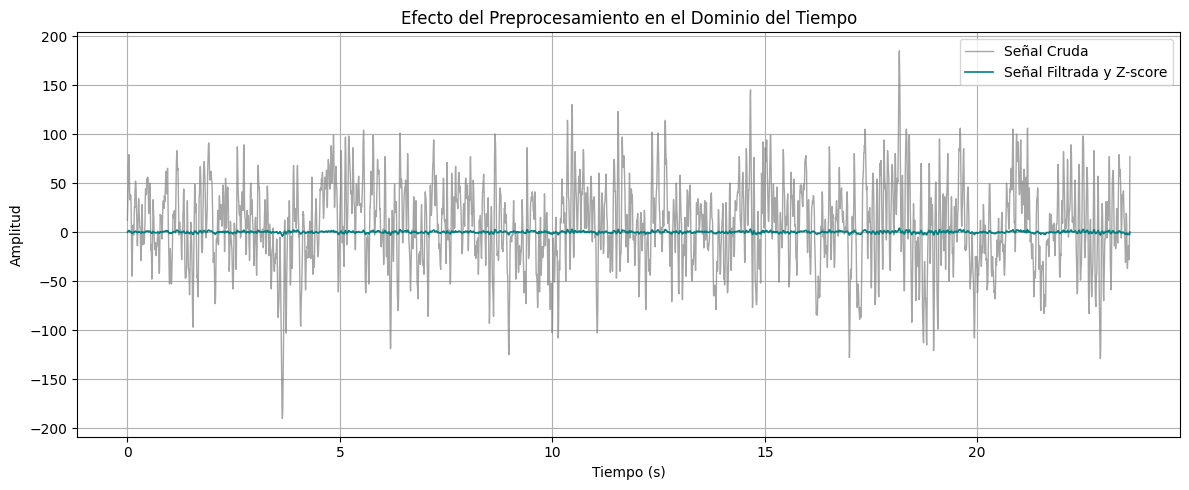

In [5]:
import sys
sys.path.append('../')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import freqz, butter, iirnotch
from src.dataset import cargar_dataset_completo

# 1. Cargar el DataFrame con la señal limpia y el dataset crudo original
df_eeg = pd.read_pickle('../data/processed/dataset_preprocesado.pkl')
df_raw = cargar_dataset_completo('../data/raw/')

def plot_respuesta_filtro(fs=173.61):
    """Grafica la magnitud de la respuesta en frecuencia del filtro combinado."""
    nyq = 0.5 * fs
    b_n, a_n = iirnotch(50.0, 30.0, fs)
    b_b, a_b = butter(4, [0.5/nyq, 60.0/nyq], btype='band')
    
    w, h_n = freqz(b_n, a_n, worN=8000)
    _, h_b = freqz(b_b, a_b, worN=8000)
    h_tot = h_n * h_b
    
    plt.figure(figsize=(10, 4))
    plt.plot(0.5 * fs * w / np.pi, 20 * np.log10(np.abs(h_tot)), color='purple', linewidth=2)
    plt.title("Respuesta en Frecuencia del Filtro (Notch 50 Hz + Pasa-banda 0.5-60 Hz)")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Ganancia (dB)")
    plt.grid(True)
    plt.xlim(0, 80)
    plt.tight_layout()
    plt.show()

def plot_raw_vs_filtrada(senal_cruda, senal_filtrada, fs=173.61):
    """Superpone la señal original frente a la señal limpia y normalizada."""
    tiempo = np.arange(len(senal_cruda)) / fs
    
    plt.figure(figsize=(12, 5))
    plt.plot(tiempo, senal_cruda, label='Señal Cruda', color='gray', alpha=0.7, linewidth=1)
    plt.plot(tiempo, senal_filtrada, label='Señal Filtrada y Z-score', color='teal', linewidth=1.2)
    plt.title("Efecto del Preprocesamiento en el Dominio del Tiempo")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Ejecutar las funciones con las fuentes correctas
plot_respuesta_filtro()
plot_raw_vs_filtrada(df_raw['senal'].iloc[0], df_eeg['senal_limpia'].iloc[0])